# 02 - Preprocessing danych

## Cel: 
Czyszczenie danych, agregacja do kroku dobowego, uzupełnianie braków medianą sezonową

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('..')

from src.data.dataset import build_meteo_dataframe, build_strzyza_level_dataframe, build_martwa_wisla_dataframe, build_port_polnocny_dataframe
from src.data.preprocessing import clean_meteo_and_day_step, fix_missing_meteo,  clean_strzyza_level_and_day_step, fix_missing_water_level,clean_martwa_wisla_and_day_step, clean_port_polnocny_and_day_step, fix_missing_port_polnocny

### Czyszczenie i Agregacja

#### Dane meteorologiczne

In [2]:
df_meteo_raw = build_meteo_dataframe()
print("Przed czyszczeniem:", df_meteo_raw.shape)

Przed czyszczeniem: (43680, 5)


In [3]:
df_meteo_clean = clean_meteo_and_day_step(df_meteo_raw)
print("Po czyszczeniu i agregacji dobowej:", df_meteo_clean.shape)
df_meteo_clean.head()

Po czyszczeniu i agregacji dobowej: (1811, 8)


,Opad_suma,Temp_średnia,Temp_min,Temp_max,Wilgotność_średnia,Ciśnienie_średnia,Ciśnienie_min,Ciśnienie_max
Dzień,,,,,,,,
2021-01-01,0.00,-1.170833,-2.2,-0.2,94.341667,1005.466667,1005.0,1006.6
2021-01-02,0.00,0.616667,-0.3,2.3,87.733333,1011.208333,1007.0,1015.7
2021-01-03,2.08,0.558333,-0.8,1.6,91.033333,1016.716667,1015.9,1017.4
2021-01-04,3.61,1.245833,0.6,1.9,90.575000,1016.441667,1015.9,1016.9
2021-01-05,18.58,2.170833,0.9,3.6,91.354167,1013.233333,1009.3,1016.3


### Metody czyszczenia 
#### Konwersja typów
- Kolumny z danymi surowymi były typu string (object)
- Wartości z przecinkiem dziesiętnym były zastępione kropką, a potem skonwertowane na typ numeryczny
#### Wartości fizycznie niemożliwe
- Wartości które nie mieściły się w zakresie fizycznie możliwych wystąpień zostały zamienione na NaN

**Meteo**
- Opad -> min: 0mm, max: 100mm
- Temperatura -> min: -30C, max: 40C
- Wilgotność -> min: 0%, max: 100%
- Ciśnienie -> min: 950 hPa, max: 1050 hPa

**Poziom wody**
- Strzyża -> min: -0.5m, max: 2.0m
- Martwa Wisła -> min: -2m, max: 2m
- Port Północny -> min: 0m, max: 10m

#### Agregacja do kroku dobowego
- Opad -> suma opadów
- Temperatura -> min, max, średnia
- Wilgotność -> średnia
- Ciśnienie -> min, max, średnia
- Poziom wody (wszystkie 3 stacje) -> średnia dobowa i maksimum dobowe

#### Dane poziomu wody w strudze Strzyża

In [4]:
df_strzyza_raw = build_strzyza_level_dataframe()
print("Przed czyszczeniem:", df_strzyza_raw.shape)

Przed czyszczeniem: (43672, 2)


In [5]:
df_strzyza_level_clean = clean_strzyza_level_and_day_step(df_strzyza_raw)
print("Po czyszczeniu i agregacji dobowej:", df_strzyza_level_clean.shape)
df_strzyza_level_clean.head()

Po czyszczeniu i agregacji dobowej: (1822, 2)


,Poziom_wody_średnia,Poziom_wody_max
Dzień,,
2021-01-01,-0.052917,0.00
2021-01-02,-0.035833,0.00
2021-01-03,0.013333,0.05
2021-01-04,0.015417,0.06
2021-01-05,0.018750,0.10


#### Dane poziomu wody w Martwej Wiśle

In [6]:
df_martwa_raw =  build_martwa_wisla_dataframe()
print("Przed czyszczeniem:", df_martwa_raw.shape)

Przed czyszczeniem: (43608, 2)


In [7]:
df_martwa_clean = clean_martwa_wisla_and_day_step(df_martwa_raw)
print("Po czyszczeniu i agregacji dobowej:", df_martwa_clean.shape)
df_martwa_clean.head()

Po czyszczeniu i agregacji dobowej: (1823, 2)


,Martwa_Wisla_średnia,Martwa_Wisla_max
Dzień,,
2021-01-01,-0.242500,-0.20
2021-01-02,-0.230417,-0.19
2021-01-03,-0.179167,-0.14
2021-01-04,-0.182917,-0.14
2021-01-05,-0.184167,-0.11


#### Dane poziomu wody w Martwej Wiśle

In [8]:
df_port_raw = build_port_polnocny_dataframe()
print("Przed czyszczeniem:", df_port_raw.shape)

Przed czyszczeniem: (43673, 2)


In [9]:
df_port_clean = clean_port_polnocny_and_day_step(df_port_raw)
print("Po czyszczeniu i agregacji dobowej:", df_port_clean.shape)
df_port_clean.head()

Po czyszczeniu i agregacji dobowej: (1785, 2)


,Port_Polnocny_średnia,Port_Polnocny_max
Dzień,,
2021-01-01,5.061250,5.10
2021-01-02,5.076250,5.12
2021-01-03,5.140417,5.20
2021-01-04,5.145833,5.20
2021-01-05,5.149167,5.24


### Analiza braków na poziomie godzinowym
#### Dane Meteo

In [10]:
import missingno as msno
import os

all_dfs = []
folder = 'data/raw/dane-pogodowe-stacja-gora-gradowa-2021-2025/'
for file in os.listdir(folder):
    if file.endswith('.xlsx'):
        df = pd.read_excel(folder + file, skipfooter=4)
        df = df.dropna(how='all')
        df.columns = df.columns.str.strip()
        all_dfs.append(df)

df_all = pd.concat(all_dfs)
cols = ['Opad [mm]', 'Temperatura [C]', 'Wilgotność [%]', 'Ciśnienie [hPa]']
for col in cols:
    df_all[col] = df_all[col].astype(str).str.replace(',', '.')
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

print("Braki w surowych danych godzinowych:")
print(df_all[cols].isnull().sum())
print("\nProcent braków:")
print((df_all[cols].isnull().sum() / len(df_all) * 100).round(2))

Braki w surowych danych godzinowych:
Opad [mm]          264
Temperatura [C]    433
Wilgotność [%]     433
Ciśnienie [hPa]    433
dtype: int64

Procent braków:
Opad [mm]          0.60
Temperatura [C]    0.99
Wilgotność [%]     0.99
Ciśnienie [hPa]    0.99
dtype: float64


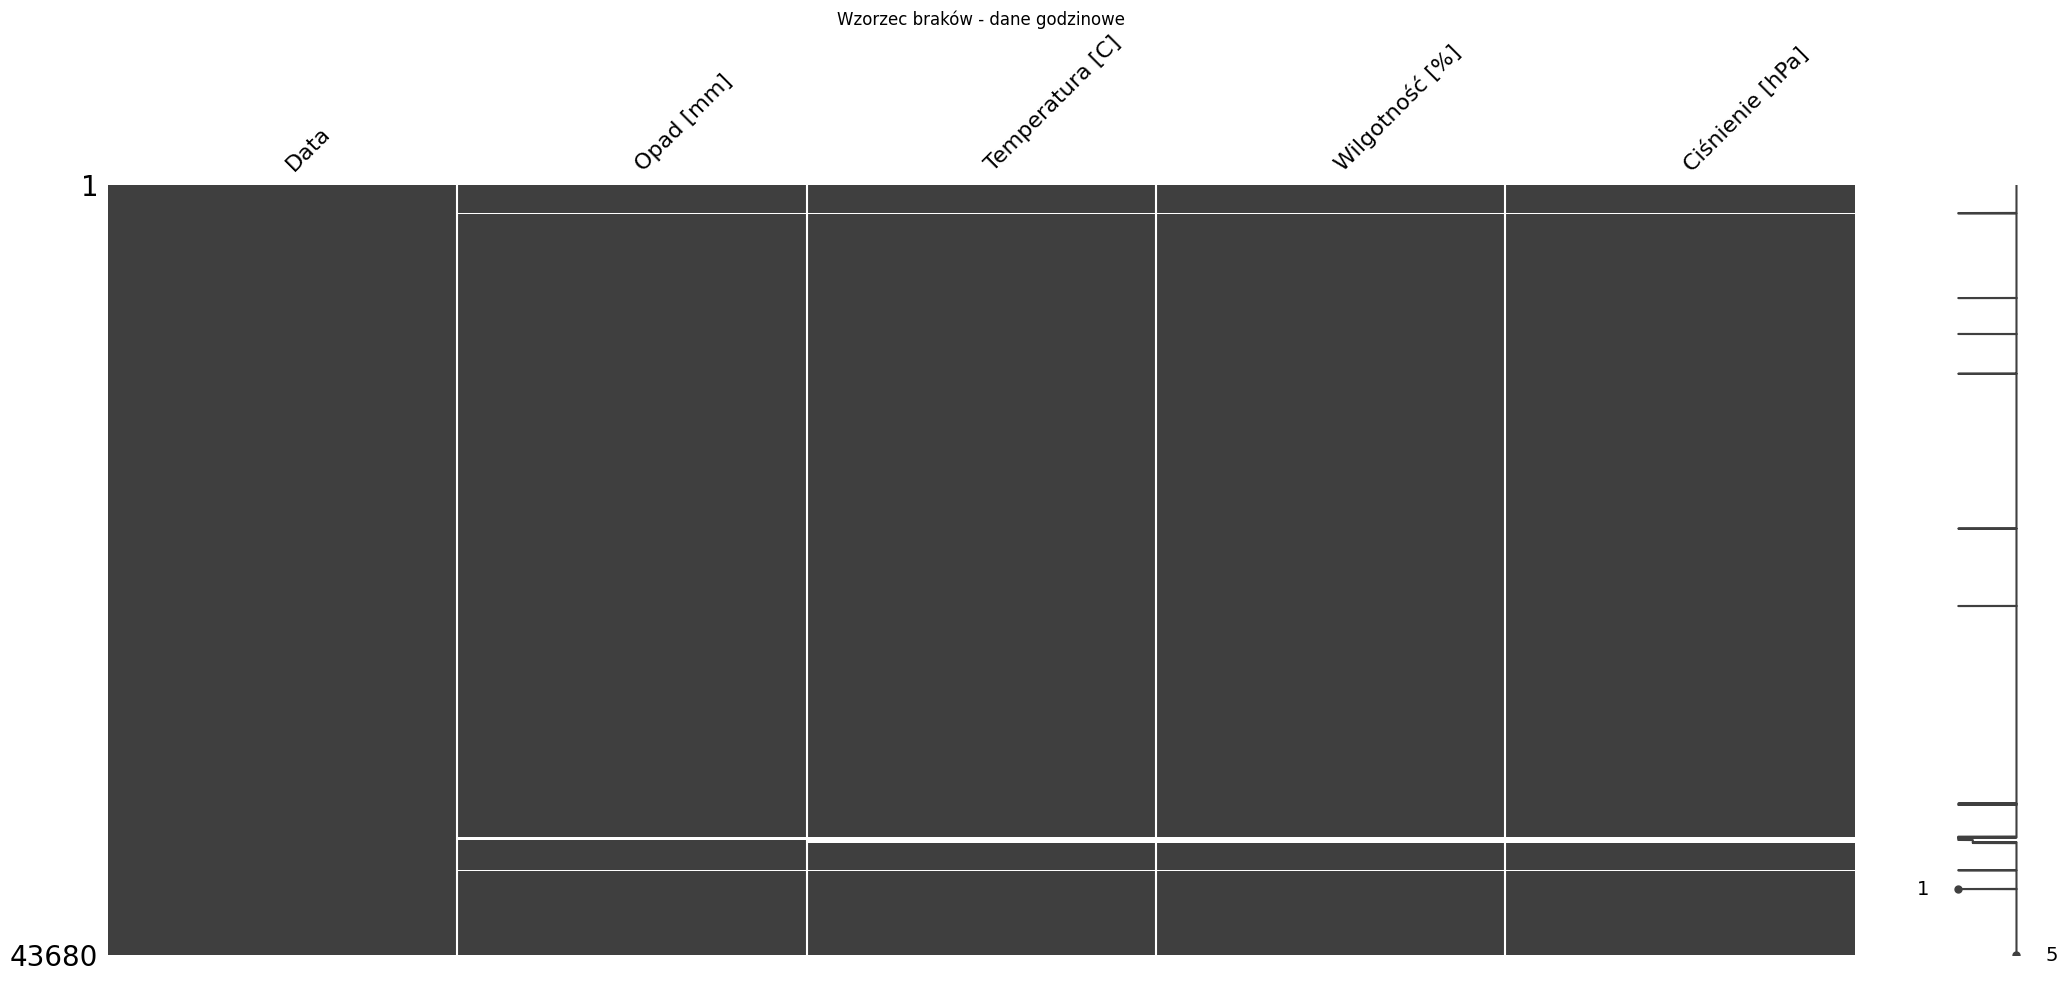

In [11]:
os.makedirs('reports/02_preprocessing', exist_ok=True)

msno.matrix(df_all)
plt.title('Wzorzec braków - dane godzinowe')
plt.savefig('reports/02_preprocessing/missing_data.png', dpi=300, bbox_inches='tight')
plt.show()

### Obserwacje z wizualizacji braków

Macierz braków (missingno) pokazuje że dane godzinowe są 
kompletne w ~99% całego okresu 2021-2025. Widoczne są jedynie
pojedyncze białe paski na końcu zbioru danych, odpowiadające
niekompletnemu ostatniemu dniu pomiarowemu.

Braki mają charakter **MCAR (Missing Completely At Random)** —
nie wykazują żadnego systematycznego wzorca czasowego ani
sezonowego, co potwierdza że są wynikiem losowych przerw
w pomiarach, a nie błędów systematycznych.

#### Dane z poziomem wody

**Strzyża**

In [12]:
df_strzyza_all = build_strzyza_level_dataframe()
df_strzyza_all['Poziom wody [m]'] = pd.to_numeric(
    df_strzyza_all['Poziom wody [m]'].astype(str).str.replace(',', '.'),
    errors='coerce'
)

**Martwa**

In [13]:
df_martwa_all = build_martwa_wisla_dataframe()
df_martwa_all['Poziom wody [m]'] = pd.to_numeric(
    df_martwa_all['Poziom wody [m]'].astype(str).str.replace(',', '.'),
    errors='coerce'
)

**Port Północny**

In [14]:
df_port_all = build_port_polnocny_dataframe()
df_port_all['Poziom wody [m]'] = pd.to_numeric(
    df_port_all['Poziom wody [m]'].astype(str).str.replace(',', '.'),
    errors='coerce'
)

In [15]:
print("Braki w danych poziomu wody:")
print(f"{'Stacja':<20} {'Braki':>8} {'Procent':>10}")
print("-" * 40)

for nazwa, df in [
    ('Strzyża', df_strzyza_all),
    ('Martwa Wisła', df_martwa_all),
    ('Port Północny', df_port_all)
]:
    braki = df['Poziom wody [m]'].isnull().sum()
    procent = round(braki / len(df) * 100, 2)
    print(f"{nazwa:<20} {braki:>8} {procent:>9}%")

Braki w danych poziomu wody:
Stacja                  Braki    Procent
----------------------------------------
Strzyża                   113      0.26%
Martwa Wisła             1483       3.4%
Port Północny            2336      5.35%


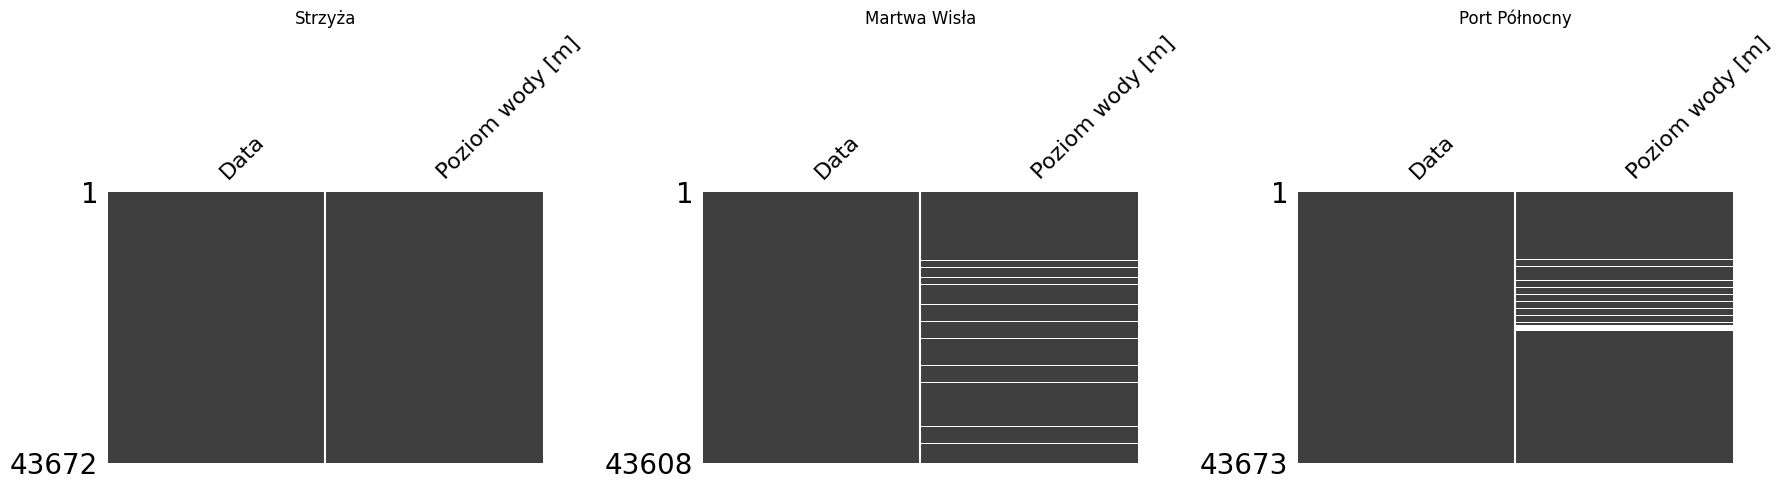

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
msno.matrix(df_strzyza_all, ax=axes[0],sparkline=False)
axes[0].set_title('Strzyża')
msno.matrix(df_martwa_all, ax=axes[1],sparkline=False)
axes[1].set_title('Martwa Wisła')
msno.matrix(df_port_all, ax=axes[2],sparkline=False)
axes[2].set_title('Port Północny')
plt.tight_layout()
plt.savefig('reports/02_preprocessing/missing_water_levels.png', dpi=300, bbox_inches='tight')
plt.show()

### Obserwacje z wizualizacji braków - stacje poziomu wody

**Strzyża** — dane praktycznie kompletne (0.26%), analogicznie 
do danych meteo. Braki mają charakter MCAR.

**Martwa Wisła** — widoczne białe paski rozłożone równomiernie 
w całym okresie pomiarowym (3.4%). Braki mają charakter MCAR — 
losowe przerwy w pomiarach bez wzorca systematycznego.
Zastosowano seasonal median imputation.

**Port Północny** — widoczna wyraźna przerwa w pomiarach 
w środkowym okresie zbioru danych (5.35%, 36 brakujących dni). 
Braki mają charakter MAR (Missing At Random) — systematyczna 
przerwa wynikająca prawdopodobnie z wyłączenia czujnika. Zastosujemy tutaj interpolacje liniowa. Ze wzgledu na duża przerwę w pobieraniu, mediana sezonowa nie oddaje poprawnie rzeczywisty trend

### Uzasadnienie wybranej strategii uzupełniania braków

Przeanalizowano możliwe strategie imputacji:

| Strategia | Ocena | Powód odrzucenia |
|-----------|-------|-----------------|
| KNN Imputer | nie | Nieuzasadniony przy <1% braków |
| Forward/backward fill | nie | Może propagować błędy pomiarowe |
| **Listwise deletion** | tak | Stosowana na poziomie godzinowym — usunięcie <1% wierszy nie zniekształca danych |
| **Seasonal median imputation** | tak | Stosowana na poziomie dobowym — zachowuje sezonowość danych |
| **Interpolacja liniowa** | tak | Port Północny — lepsza dla ciągłej przerwy 36 dni |

### Dlaczego agregacja jest bezpieczna?

Dane godzinowe są kompletne w ~99%. Oznacza to że:
- Każdy dzień ma prawie kompletne 24 godziny pomiarów
- Agregacja dobowa (średnia/suma z dostępnych godzin) 
  jest reprezentatywna
- Braki godzinowe są "absorbowane" przez groupby
- Jedyne realne braki to brakujące całe dni po reindex

### Podsumowanie zastosowanych strategii
- **Meteo + Strzyża + Martwa Wisła** → seasonal median imputation
- **Port Północny** → interpolacja liniowa (36 dni ciągłej przerwy)

### Uzupełnianie Brakujących danych

#### Dane meteorologiczne

In [17]:
print("Braki przed uzupełnieniem:")
print(df_meteo_clean.isnull().sum())

Braki przed uzupełnieniem:
Opad_suma             0
Temp_średnia          0
Temp_min              0
Temp_max              0
Wilgotność_średnia    0
Ciśnienie_średnia     0
Ciśnienie_min         0
Ciśnienie_max         0
dtype: int64


In [18]:
df_meteo_filled = fix_missing_meteo(df_meteo_clean)

print("\nBraki po uzupełnieniu:")
print(df_meteo_filled.isnull().sum())


Braki po uzupełnieniu:
Opad_suma             0
Temp_średnia          0
Temp_min              0
Temp_max              0
Wilgotność_średnia    0
Ciśnienie_średnia     0
Ciśnienie_min         0
Ciśnienie_max         0
month                 0
dtype: int64


#### Dane poziomu wody - Strzyża

In [19]:
print("Braki przed uzupełnieniem:")
print(df_strzyza_level_clean.isnull().sum())

Braki przed uzupełnieniem:
Poziom_wody_średnia    0
Poziom_wody_max        0
dtype: int64


In [20]:
full_range = pd.date_range(start=df_strzyza_level_clean.index.min(),
                           end=df_strzyza_level_clean.index.max(), freq='D')
df_strzyza_reindexed = df_strzyza_level_clean.reindex(full_range)
print("Strzyża po reindex:")
print(df_strzyza_reindexed.isnull().sum())

Strzyża po reindex:
Poziom_wody_średnia    4
Poziom_wody_max        4
dtype: int64


In [21]:
df_strzyza_filled = fix_missing_water_level(df_strzyza_level_clean)
print("\nBraki po uzupełnieniu - Strzyża:")
print(df_strzyza_filled.isnull().sum())


Braki po uzupełnieniu - Strzyża:
Poziom_wody_średnia    0
Poziom_wody_max        0
month                  0
dtype: int64


#### Dane poziomu wody - Martwa Wisła

In [22]:
print("\nBraki przed uzupełnieniem - Martwa Wisła:")
print(df_martwa_clean.isnull().sum())


Braki przed uzupełnieniem - Martwa Wisła:
Martwa_Wisla_średnia    0
Martwa_Wisla_max        0
dtype: int64


In [23]:
full_range = pd.date_range(start=df_martwa_clean.index.min(),
                           end=df_martwa_clean.index.max(), freq='D')
df_martwa_reindexed = df_martwa_clean.reindex(full_range)
print("\nMartwa Wisła po reindex:")
print(df_martwa_reindexed.isnull().sum())


Martwa Wisła po reindex:
Martwa_Wisla_średnia    3
Martwa_Wisla_max        3
dtype: int64


In [24]:
df_martwa_filled = fix_missing_water_level(df_martwa_clean)
print("\nBraki po uzupełnieniu - Martwa Wisła:")
print(df_martwa_filled.isnull().sum())


Braki po uzupełnieniu - Martwa Wisła:
Martwa_Wisla_średnia    0
Martwa_Wisla_max        0
month                   0
dtype: int64


#### Dane poziomu wody - Port Północny

In [25]:
print("Braki przed reindex - Port Północny:")
print(df_port_clean.isnull().sum())

Braki przed reindex - Port Północny:
Port_Polnocny_średnia    0
Port_Polnocny_max        0
dtype: int64


In [26]:
full_range = pd.date_range(start=df_port_clean.index.min(),
                           end=df_port_clean.index.max(), freq='D')
df_port_reindexed = df_port_clean.reindex(full_range)
print("\nBraki po reindex (przed uzupełnieniem):")
print(df_port_reindexed.isnull().sum())


Braki po reindex (przed uzupełnieniem):
Port_Polnocny_średnia    41
Port_Polnocny_max        41
dtype: int64


In [27]:
df_port_filled = fix_missing_port_polnocny(df_port_clean)
print("\nBraki po uzupełnieniu interpolacją:")
print(df_port_filled.isnull().sum())


Braki po uzupełnieniu interpolacją:
Port_Polnocny_średnia    0
Port_Polnocny_max        0
month                    0
dtype: int64


## Podsumowanie


Po przeprowadzeniu preprocessingu dane są gotowe do dalszej analizy:

- **Dane meteo:** 43 680 wierszy godzinowych → 1811 dni dobowych
- **Strzyża:** 43 672 wierszy godzinowych → 1822 dni dobowych
- **Martwa Wisła:** 43 608 wierszy godzinowych → 1826 dni dobowych
- **Port Północny:** 43 673 wierszy godzinowych → 1826 dni dobowych 
  (36 dni uzupełnionych interpolacją liniową)

Brak braków we wszystkich zbiorach po przetworzeniu.
Dane gotowe do feature engineering (notebook 03).